# Indigenous Fire Stewardship Opportunity Map
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** Census TIGER AIANNH, MTBS, LANDFIRE EVT (optional), Tribal input (required)

## Overview
This notebook identifies opportunities to restore Indigenous fire stewardship practices
that can reduce catastrophic wildfire risk, restore cultural and ecological relationships,
enhance biodiversity, and strengthen community safety and resilience.

## Framework: Indigenous Fire Stewardship Principles
This analysis:
- Recognizes Indigenous peoples as the original fire stewards
- Respects Tribal sovereignty over traditional practices
- **Never presumes to define 'correct' cultural burning** — that belongs to each Tribal Nation
- Supports Tribal-led fire management decisions
- Acknowledges that Western science is one knowledge system among many
- Centers Indigenous knowledge and self-determination

## Data Notes
| Component | Data Source | Status |
|---|---|---|
| Tribal land boundaries | Census TIGER AIANNH | Real |
| Fire history / risk | MTBS (1984–present) | Real |
| Vegetation / ecosystem types | LANDFIRE EVT | **Synthetic placeholder** - see Section 3 |
| Historical cultural fire areas | Tribal knowledge | **Requires Tribal engagement** - never substitute |
| Fire practitioners | Direct Tribal contact | **Requires Tribal engagement** - placeholder only |
| Carbon estimates | Derived from vegetation | Approximate - depends on vegetation data |

## Research Questions
- Where could cultural fire reduce fast-fire risk on Tribal lands?
- What landscapes are ecologically suitable for cultural burning?
- What co-benefits would cultural fire provide?

## Outputs
- Cultural fire opportunity scores by Tribal land unit
- Co-benefits analysis (biodiversity, carbon, community safety)
- Opportunity maps per Tribal land
- Priority ranking dashboard

In [20]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, box
from shapely.ops import unary_union
from shapely.validation import make_valid

from src.data import constants, loaders, validators
from src.data.constants import PRIMARY_TRIBES
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import (
    generate_citations,
    print_data_acknowledgment,
    print_tek_disclaimer,
)
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {constants.OUTPUTS_DIR}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs
Analysis run: 2026-04-01 17:50


In [21]:
# Data sovereignty and TEK acknowledgment 
print_data_acknowledgment(source_keys=["census_aiannh", "mtbs"])
print()
print_tek_disclaimer()

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by three
complementary data governance frameworks:

OCAP® — Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE  — Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR  — Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

We recognize that:

• Tribal Nations are sovereign governments with the right to control
  data about their own communities and terr

## Framework

In [22]:
# Indigenous Fire Stewardship Framework
STEWARDSHIP_PRINCIPLES = {
    "sovereignty": {
        "description": "Tribal sovereignty over fire management decisions",
        "implementation": "Tribal-led planning and execution",
        "priority": 1,
    },
    "traditional_knowledge": {
        "description": "Indigenous knowledge systems guide practices",
        "implementation": "Elder consultation and cultural protocols",
        "priority": 1,
    },
    "ecological_restoration": {
        "description": "Restore fire-adapted ecosystems",
        "implementation": "Fire return interval restoration",
        "priority": 2,
    },
    "cultural_continuity": {
        "description": "Maintain cultural practices and relationships",
        "implementation": "Intergenerational knowledge transfer",
        "priority": 1,
    },
    "community_safety": {
        "description": "Protect communities from catastrophic fire",
        "implementation": "Strategic fuel reduction",
        "priority": 2,
    },
}

# Analysis parameters
ANALYSIS_CONFIG = {
    "historical_fire_return_interval": {
        "frequent":   (0, 15),     # Grasslands, oak woodlands
        "moderate":   (15, 35),    # Pine forests
        "infrequent": (35, 100),   # Mixed conifer
    },
    "suitable_vegetation_types": [
        "Grassland", "Oak Woodland", "Pine Forest",
        "Mixed Conifer", "Shrubland", "Riparian",
    ],
    "practitioner_distance_km": 50,
    "burn_window_months": [3, 4, 5, 10, 11],
}

print("INDIGENOUS FIRE STEWARDSHIP FRAMEWORK")
print("=" * 60)
for name, config in STEWARDSHIP_PRINCIPLES.items():
    print(f"\n{name.replace('_', ' ').title()} (Priority {config['priority']}):")
    print(f"  {config['description']}")
print("\nWestern science serves to support, not replace, traditional practices.")

INDIGENOUS FIRE STEWARDSHIP FRAMEWORK

Sovereignty (Priority 1):
  Tribal sovereignty over fire management decisions

Traditional Knowledge (Priority 1):
  Indigenous knowledge systems guide practices

Ecological Restoration (Priority 2):
  Restore fire-adapted ecosystems

Cultural Continuity (Priority 1):
  Maintain cultural practices and relationships

Community Safety (Priority 2):
  Protect communities from catastrophic fire

Western science serves to support, not replace, traditional practices.


## Load Tribal Land Boundaries and Fire History

In [23]:
# Tribal land boundaries 
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal, "census_aiannh", required_columns=["geometry", "NAME"]
)
tribal_lands = all_tribal[all_tribal["NAME"].isin(PRIMARY_TRIBES)].copy()
tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False).reset_index(drop=True)
tribal_lands["geometry"] = tribal_lands.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
CONUS = geo_utils.bbox_geodataframe((-127, 24, -65, 50)).geometry.iloc[0]
tribal_lands = tribal_lands[
    tribal_lands.geometry.notnull() &
    tribal_lands.geometry.is_valid &
    tribal_lands.intersects(CONUS)
].copy().reset_index(drop=True)

# Geometry metrics
tribal_proj = tribal_lands.to_crs("EPSG:5070")
tribal_lands["area_km2"]     = tribal_proj.geometry.area / 1e6
tribal_lands["area_acres"]   = tribal_lands["area_km2"] * 247.105
tribal_lands["perimeter_km"] = tribal_proj.geometry.length / 1000
tribal_lands["edge_ratio"]   = tribal_lands["perimeter_km"] / tribal_lands["area_km2"]

print(f"Tribal Nations loaded: {len(tribal_lands)}")
tribal_lands[["NAME", "area_acres", "edge_ratio"]].round(1)

Tribal Nations loaded: 10


,NAME,area_acres,edge_ratio
0,Cherokee,4456459.7,0.0
1,Chickasaw,4755502.4,0.0
2,Choctaw,6985235.6,0.0
3,Colville,1398495.5,0.1
4,Creek,3062676.4,0.0
5,Fort Apache,1684000.5,0.1
6,Kiowa-Comanche-Apache-Fort Sill Apache,4114570.6,0.0
7,Osage,1474576.6,0.1
8,San Carlos,1872894.8,0.1
9,Warm Springs,654773.2,0.1


In [24]:
# Fire history from MTBS
MTBS_LOCAL = constants.RAW_DIR / "mtbs_perimeters" / "mtbs_perims_DD.shp"

if MTBS_LOCAL.exists():
    fire_gdf = gpd.read_file(MTBS_LOCAL)
    fire_gdf.columns = fire_gdf.columns.str.lower()
    fire_gdf["ig_date"] = pd.to_datetime(fire_gdf["ig_date"], errors="coerce")
    fire_gdf["fire_year"] = fire_gdf["ig_date"].dt.year
    if "burnbndac" in fire_gdf.columns:
        fire_gdf["fire_size_acres"] = fire_gdf["burnbndac"]
    fire_gdf = fire_gdf.to_crs(constants.CRS_GEOGRAPHIC)

    # Spatial join to get per-Tribe fire counts
    joined = gpd.sjoin(
        fire_gdf[["geometry", "fire_size_acres"]].to_crs("EPSG:5070"),
        tribal_lands[["NAME", "geometry"]].to_crs("EPSG:5070"),
        how="inner", predicate="intersects",
    )
    fire_freq = joined.groupby("NAME").agg(
        fire_count=("fire_size_acres", "count"),
        total_acres_burned=("fire_size_acres", "sum"),
    ).reset_index()
    fire_freq["fire_risk_score"] = (
        fire_freq["fire_count"] / fire_freq["fire_count"].max() * 10
    ).round(2)
    tribal_lands = tribal_lands.merge(fire_freq, on="NAME", how="left")
    tribal_lands["fire_count"]      = tribal_lands["fire_count"].fillna(0)
    tribal_lands["fire_risk_score"] = tribal_lands["fire_risk_score"].fillna(0)
    MTBS_AVAILABLE = True
    print("MTBS fire history loaded.")
    print(tribal_lands[["NAME", "fire_count", "fire_risk_score"]].to_string(index=False))
else:
    tribal_lands["fire_count"]      = np.nan
    tribal_lands["fire_risk_score"] = 5.0  # Neutral default
    MTBS_AVAILABLE = False
    print(
        "MTBS not found at data/raw/mtbs_perimeters/mtbs_perims_DD.shp.\n"
        "Fire risk defaulting to neutral (5.0). Download from https://www.mtbs.gov"
    )

MTBS fire history loaded.
                                  NAME  fire_count  fire_risk_score
                              Cherokee          97             4.71
                             Chickasaw          74             3.59
                               Choctaw         206            10.00
                              Colville          71             3.45
                                 Creek         125             6.07
                           Fort Apache         104             5.05
Kiowa-Comanche-Apache-Fort Sill Apache          84             4.08
                                 Osage         173             8.40
                            San Carlos         109             5.29
                          Warm Springs          63             3.06


## Vegetation Data

> **SYNTHETIC PLACEHOLDER**> 
> Vegetation types below are randomly assigned for framework demonstration.
> Real analysis requires LANDFIRE Existing Vegetation Type (EVT) raster data.
> 
> **To use real vegetation data:**
> 1. Download LANDFIRE EVT from https://www.landfire.gov/evt.php
> 2. Place in `data/raw/landfire/`
> 3. Replace the cell below with `rioxarray` raster extraction per Tribal land
> 
> Results with synthetic vegetation data are illustrative only.

In [25]:
# Vegetation (SYNTHETIC PLACEHOLDER) 
# NOTE: These vegetation type distributions are randomly generated.
# Replace with LANDFIRE EVT extraction for real analysis.
# See notebook header for download instructions.

LANDFIRE_PATH = constants.RAW_DIR / "landfire" / "US_220EVT" / "US_220EVT.tif"
LANDFIRE_AVAILABLE = LANDFIRE_PATH.exists()

# Vegetation type definitions with ecological fire parameters
VEG_TYPES = {
    "Grassland":     {"hfri_years": 5,  "suitability": 9,  "fuel_tons_acre": 2,  "reduction_pct": 0.70},
    "Oak Woodland":  {"hfri_years": 8,  "suitability": 10, "fuel_tons_acre": 8,  "reduction_pct": 0.50},
    "Pine Forest":   {"hfri_years": 15, "suitability": 8,  "fuel_tons_acre": 25, "reduction_pct": 0.40},
    "Mixed Conifer": {"hfri_years": 30, "suitability": 6,  "fuel_tons_acre": 35, "reduction_pct": 0.30},
    "Shrubland":     {"hfri_years": 10, "suitability": 8,  "fuel_tons_acre": 12, "reduction_pct": 0.60},
    "Riparian":      {"hfri_years": 5,  "suitability": 5,  "fuel_tons_acre": 6,  "reduction_pct": 0.40},
}

if LANDFIRE_AVAILABLE:
    print("LANDFIRE EVT found — replace this cell with rioxarray extraction.")
    # TODO: implement rioxarray-based EVT extraction per Tribal land
    # import rioxarray as rxr
    # evt = rxr.open_rasterio(LANDFIRE_PATH, masked=True)
    # ...
    print("⚠ Using synthetic placeholder until LANDFIRE extraction is implemented.")

# Generate synthetic vegetation grid per Tribal land
rng = np.random.default_rng(seed=2024)  # Fixed seed for reproducibility
veg_records = []
GRID_DEG = 0.05  # ~5 km cell size

for _, tribe in tribal_lands.iterrows():
    bounds = tribe.geometry.bounds
    xs = np.arange(bounds[0], bounds[2], GRID_DEG)
    ys = np.arange(bounds[1], bounds[3], GRID_DEG)
    for x in xs:
        for y in ys:
            cell = box(x, y, x + GRID_DEG, y + GRID_DEG)
            if not tribe.geometry.intersects(cell):
                continue
            veg_name = rng.choice(list(VEG_TYPES.keys()))
            veg      = VEG_TYPES[veg_name]
            veg_records.append({
                "NAME":                   tribe["NAME"],
                "fire_risk_score":        tribe["fire_risk_score"],
                "vegetation_type":        veg_name,
                "hfri_years":             int(veg["hfri_years"] * rng.uniform(0.8, 1.2)),
                "base_suitability":       veg["suitability"],
                "fuel_tons_acre":         veg["fuel_tons_acre"],
                "fuel_reduction_pct":     veg["reduction_pct"],
                "geometry":               cell,
            })

vegetation = gpd.GeoDataFrame(veg_records, crs=constants.CRS_GEOGRAPHIC)

# Area in acres
vegetation["area_acres"] = (
    vegetation.to_crs("EPSG:5070").geometry.area / 4047
)

print(f"Vegetation data: SYNTHETIC PLACEHOLDER ({len(vegetation):,} grid cells)")
print("   Replace with LANDFIRE EVT for real analysis.")
print(f"\nVegetation type distribution:")
print(vegetation["vegetation_type"].value_counts().to_string())

Vegetation data: SYNTHETIC PLACEHOLDER (5,552 grid cells)
   Replace with LANDFIRE EVT for real analysis.

Vegetation type distribution:
vegetation_type
Grassland        955
Riparian         950
Pine Forest      944
Mixed Conifer    934
Shrubland        897
Oak Woodland     872


## Historical Cultural Fire Areas

> **REQUIRES TRIBAL ENGAGEMENT**
> 
> Historical cultural fire use areas represent Traditional Ecological Knowledge
> that belongs to each Tribal Nation. These polygons cannot be generated
> algorithmically or inferred from remote sensing.
> 
> **To populate real data:**
> - Consult Tribal elders and cultural practitioners
> - Work with Tribal historians and cultural resource departments
> - Review ethnohistorical records under Tribal direction
> - Use fire scar data only with Tribal interpretation
> - Ensure data sovereignty; Tribal Nations own this knowledge
> 
> The template below shows the expected schema. Add real entries
> as they are provided by and approved by each Tribal Nation.

In [26]:
# Historical cultural fire areas (REQUIRES TRIBAL INPUT)
# This is a schema template. Real entries must come from Tribal Nations directly.
# Do not populate with estimates or inferences, consult with the appropriate Tribal Nation first.

# Schema:
# NAME             : Tribal Nation (must match PRIMARY_TRIBES Census NAME)
# use_type         : Type of cultural fire use
# traditional_purpose: Cultural/ecological purpose
# fire_frequency   : Traditional fire return interval
# season           : Preferred burn season
# knowledge_source : How this knowledge was shared
# confidence       : High / Moderate / Low
# geometry         : Polygon (from Tribal GIS or hand-drawn with Tribal guidance)

HISTORICAL_FIRE_AREAS_SCHEMA = [
    # Example entry — replace with real Tribal-provided data:
    # {
    #     "NAME": "Warm Springs",
    #     "use_type": "Camas Prairie Management",
    #     "traditional_purpose": "Camas bulb production",
    #     "fire_frequency": "Annual to biennial",
    #     "season": "Fall",
    #     "knowledge_source": "Tribal Elder consultation",
    #     "confidence": "High",
    #     "geometry": <Polygon from Tribal GIS>,
    # }
]

if HISTORICAL_FIRE_AREAS_SCHEMA:
    historical_fire_areas = gpd.GeoDataFrame(
        HISTORICAL_FIRE_AREAS_SCHEMA, crs=constants.CRS_GEOGRAPHIC
    )
    print(f"Historical fire areas loaded: {len(historical_fire_areas)}")
else:
    historical_fire_areas = gpd.GeoDataFrame(
        columns=["NAME", "use_type", "traditional_purpose",
                 "fire_frequency", "season", "knowledge_source",
                 "confidence", "geometry"],
        geometry="geometry",
    )
    historical_fire_areas.crs = constants.CRS_GEOGRAPHIC
    print(
        "No historical cultural fire areas defined.\n"
        "   Populate HISTORICAL_FIRE_AREAS_SCHEMA with Tribal-provided data.\n"
        "   Historical use bonus will not be applied to opportunity scores."
    )

No historical cultural fire areas defined.
   Populate HISTORICAL_FIRE_AREAS_SCHEMA with Tribal-provided data.
   Historical use bonus will not be applied to opportunity scores.


## Fire Practitioners

> **REQUIRES TRIBAL ENGAGEMENT — PLACEHOLDER ONLY**
> 
> Practitioner data is not available from any public API.
> Sources for real data:
> - Direct contact with Tribal fire departments
> - Indigenous Peoples Burning Network (IPBN): www.indigenouspeoplesburningnetwork.org
> - BIA Division of Fire Management Tribal program directory
> - Inter-Tribal Timber Council
> 
> Update `PRACTITIONERS` below with verified information AFTER consultation and approval. 

In [27]:
# Fire practitioners (PLACEHOLDER REQUIRES REAL DATA IF APPROVED)
# Replace with real practitioner information.
# Coordinates should be approximate crew headquarters, not personal addresses.

PRACTITIONERS = [
    # Example schema — replace with verified data:
    # {
    #     "NAME":                     "Colville",  # associated Tribal Nation
    #     "crew_name":                "Colville Tribal Fire Management",
    #     "crew_type":                "Tribal Crew",
    #     "crew_size":                20,
    #     "cultural_burn_trained":    True,
    #     "traditional_knowledge":    True,
    #     "burn_boss_qualified":       4,
    #     "lon":                      -118.8,
    #     "lat":                      48.2,
    # }
]

if PRACTITIONERS:
    practitioners = gpd.GeoDataFrame(
        PRACTITIONERS,
        geometry=[Point(p["lon"], p["lat"]) for p in PRACTITIONERS],
        crs=constants.CRS_GEOGRAPHIC,
    )
    print(f"Practitioners loaded: {len(practitioners)}")
    print(f"Total crew members: {practitioners['crew_size'].sum()}")
else:
    practitioners = None
    print(
        "No practitioner data defined.\n"
        "   Populate PRACTITIONERS with verified crew information.\n"
        "   Accessibility component will default to neutral score."
    )

No practitioner data defined.
   Populate PRACTITIONERS with verified crew information.
   Accessibility component will default to neutral score.


## Opportunity Analysis

In [28]:
# Ecological suitability score
# Base suitability from vegetation type (real ecological parameters)
# combined with fire deficit relative to historical return interval.
# NOTE: Suitability scores are real; vegetation inputs are synthetic.

# Estimate years since last fire from MTBS where available
# When MTBS is not available, use a conservative placeholder
if MTBS_AVAILABLE:
    # Estimate years since fire as 2024 minus the most recent MTBS fire year
    # per grid cell. Simplified here as a Tribal-land-level estimate.
    recent_year = fire_gdf["fire_year"].max()
    # years_since_fire varies by cell; use fire_risk_score as proxy
    # Higher risk score → more fire history → shorter effective interval
    vegetation["years_since_fire"] = (
        150 - vegetation["fire_risk_score"].clip(0, 10) * 10
    ).astype(int).clip(lower=10)
else:
    vegetation["years_since_fire"] = 75  # Conservative placeholder

vegetation["interval_deviation"] = (
    vegetation["years_since_fire"] / vegetation["hfri_years"].clip(lower=1)
)
vegetation["deficit_bonus"] = np.where(
    vegetation["interval_deviation"] > 3, 2,
    np.where(vegetation["interval_deviation"] > 2, 1, 0)
)

vegetation["ecological_suitability"] = (
    vegetation["base_suitability"] * 0.6 +
    vegetation["deficit_bonus"] * 2 +
    np.minimum(vegetation["fire_risk_score"] / 2, 2)
).clip(0, 10)

print("Ecological suitability computed.")
print(f"Mean: {vegetation['ecological_suitability'].mean():.2f}")
print(f"\nSuitability by vegetation type:")
print(vegetation.groupby("vegetation_type")["ecological_suitability"].mean().round(2).to_string())

Ecological suitability computed.
Mean: 9.56

Suitability by vegetation type:
vegetation_type
Grassland        10.00
Mixed Conifer     8.50
Oak Woodland     10.00
Pine Forest       9.96
Riparian          8.94
Shrubland        10.00


In [29]:
# Practitioner accessibility score
MAX_DIST_KM = ANALYSIS_CONFIG["practitioner_distance_km"]

if practitioners is not None and len(practitioners) > 0:
    veg_proj  = vegetation.to_crs("EPSG:5070")
    prac_proj = practitioners.to_crs("EPSG:5070")
    distances = []
    cultural_avail = []
    for _, row in veg_proj.iterrows():
        dists = prac_proj.geometry.distance(row.geometry.centroid)
        idx   = dists.idxmin()
        distances.append(dists.min() / 1000)
        cultural_avail.append(
            bool(prac_proj.loc[idx, "cultural_burn_trained"])
        )
    vegetation["dist_to_practitioners_km"] = distances
    vegetation["cultural_trained_avail"]   = cultural_avail
    vegetation["accessibility_score"] = (
        10 - (vegetation["dist_to_practitioners_km"] / MAX_DIST_KM * 10)
    ).clip(0, 10)
    vegetation.loc[vegetation["cultural_trained_avail"], "accessibility_score"] = (
        vegetation.loc[vegetation["cultural_trained_avail"], "accessibility_score"] + 2
    ).clip(upper=10)
else:
    vegetation["accessibility_score"]   = 5.0  # Neutral default
    vegetation["cultural_trained_avail"] = False
    print("Practitioner data not available; accessibility defaulting to neutral (5.0).")

print(f"Mean accessibility score: {vegetation['accessibility_score'].mean():.2f}")

Practitioner data not available; accessibility defaulting to neutral (5.0).
Mean accessibility score: 5.00


In [30]:
# Composite opportunity score 
# Ecological suitability (40%) + fire risk benefit (30%) + accessibility (20%)
# + historical use bonus (10% if data available)

vegetation["base_opportunity"] = (
    vegetation["ecological_suitability"] * 0.40 +
    vegetation["fire_risk_score"]        * 0.30 +
    vegetation["accessibility_score"]   * 0.20
)

# Historical use bonus (only applied if real data provided)
vegetation["historical_use"] = False
if not historical_fire_areas.empty:
    for _, hist_area in historical_fire_areas.iterrows():
        mask = (
            vegetation["NAME"] == hist_area["NAME"]
        ) & vegetation.geometry.intersects(hist_area.geometry)
        vegetation.loc[mask, "historical_use"] = True

vegetation["opportunity_score"] = (
    vegetation["base_opportunity"] +
    vegetation["historical_use"].astype(int) * 1.0
).clip(0, 10)

vegetation["opportunity_category"] = pd.cut(
    vegetation["opportunity_score"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Moderate", "High"],
)

print("CULTURAL FIRE OPPORTUNITY SCORES")
print("=" * 50)
print(f"Mean: {vegetation['opportunity_score'].mean():.2f}")
print(f"\nDistribution:")
print(vegetation["opportunity_category"].value_counts().to_string())
print(f"\nBy Tribal Nation:")
print(
    vegetation.groupby("NAME")["opportunity_score"]
    .mean().round(2).sort_values(ascending=False).to_string()
)

CULTURAL FIRE OPPORTUNITY SCORES
Mean: 6.58

Distribution:
opportunity_category
Moderate    4285
High        1267
Low            0

By Tribal Nation:
NAME
Choctaw                                   7.68
Osage                                     7.22
Creek                                     6.65
San Carlos                                6.46
Fort Apache                               6.40
Cherokee                                  6.30
Kiowa-Comanche-Apache-Fort Sill Apache    6.12
Chickasaw                                 5.96
Colville                                  5.89
Warm Springs                              5.74


## Co-Benefits Analysis
> **Note:** Co-benefit estimates use real area calculations (Census TIGER) and
> scientifically grounded fuel reduction factors, but depend on synthetic
> vegetation type assignments. Results are illustrative.

In [31]:
# Biodiversity benefits
BIODIVERSITY_SCORES = {
    "Grassland":     9,
    "Oak Woodland":  10,
    "Pine Forest":   7,
    "Mixed Conifer": 6,
    "Shrubland":     8,
    "Riparian":      7,
}
NATIVE_PLANT_VEG = {"Grassland", "Oak Woodland", "Shrubland"}
POLLINATOR_VEG   = {"Grassland", "Oak Woodland", "Riparian"}
WILDLIFE_VEG     = {"Oak Woodland", "Pine Forest", "Riparian"}

vegetation["biodiversity_benefit"]    = vegetation["vegetation_type"].map(BIODIVERSITY_SCORES)
vegetation["native_plant_benefit"]    = vegetation["vegetation_type"].isin(NATIVE_PLANT_VEG)
vegetation["pollinator_benefit"]      = vegetation["vegetation_type"].isin(POLLINATOR_VEG)
vegetation["wildlife_habitat_benefit"] = vegetation["vegetation_type"].isin(WILDLIFE_VEG)

# Carbon benefits 
vegetation["fuel_reduced_tons_acre"] = (
    vegetation["fuel_tons_acre"] * vegetation["fuel_reduction_pct"]
)
vegetation["total_fuel_reduction_tons"] = (
    vegetation["fuel_reduced_tons_acre"] * vegetation["area_acres"]
)
# Wildfire emissions avoided: prescribed fire emits ~3x less than wildfire
vegetation["wildfire_emissions_avoided_tons"] = (
    vegetation["total_fuel_reduction_tons"] * 3
)
max_emission = vegetation["wildfire_emissions_avoided_tons"].quantile(0.95)
vegetation["carbon_benefit_score"] = (
    vegetation["wildfire_emissions_avoided_tons"] / max_emission * 10
).clip(0, 10)

# Community safety benefits 
# Use distance from Tribal boundary as proxy for community proximity
tribal_proj = tribal_lands.to_crs("EPSG:5070")
veg_proj    = vegetation.to_crs("EPSG:5070")

dist_to_community = []
for _, row in veg_proj.iterrows():
    tribe_boundary = tribal_proj[tribal_proj["NAME"] == row["NAME"]].geometry
    if tribe_boundary.empty:
        dist_to_community.append(np.nan)
    else:
        # Use boundary of the full geometry — works for both Polygon and MultiPolygon
        dist_to_community.append(
            tribe_boundary.iloc[0].boundary.distance(row.geometry.centroid) / 1000
        )

vegetation["dist_to_community_km"] = dist_to_community
vegetation["community_safety_benefit"] = (
    (10 - vegetation["dist_to_community_km"].clip(upper=20) / 20 * 10) * 0.5 +
    vegetation["fire_risk_score"] * 0.5
).clip(0, 10)

# Composite co-benefits score 
vegetation["co_benefits_score"] = (
    vegetation["biodiversity_benefit"]    * 0.30 +
    vegetation["carbon_benefit_score"]    * 0.30 +
    vegetation["community_safety_benefit"] * 0.40
)
vegetation["co_benefits_category"] = pd.cut(
    vegetation["co_benefits_score"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Moderate", "High"],
)

print("CO-BENEFITS ANALYSIS")
print("=" * 50)
print(f"Total fuel reduction: {vegetation['total_fuel_reduction_tons'].sum():,.0f} tons")
print(f"Emissions avoided   : {vegetation['wildfire_emissions_avoided_tons'].sum():,.0f} tons CO2e")
print(f"Mean biodiversity   : {vegetation['biodiversity_benefit'].mean():.2f}/10")
print(f"Mean safety benefit : {vegetation['community_safety_benefit'].mean():.2f}/10")

CO-BENEFITS ANALYSIS
Total fuel reduction: 202,321,702 tons
Emissions avoided   : 606,965,107 tons CO2e
Mean biodiversity   : 7.81/10
Mean safety benefit : 5.06/10


## Visualizations

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\indigenous_fire_stewardship_opportunity.png


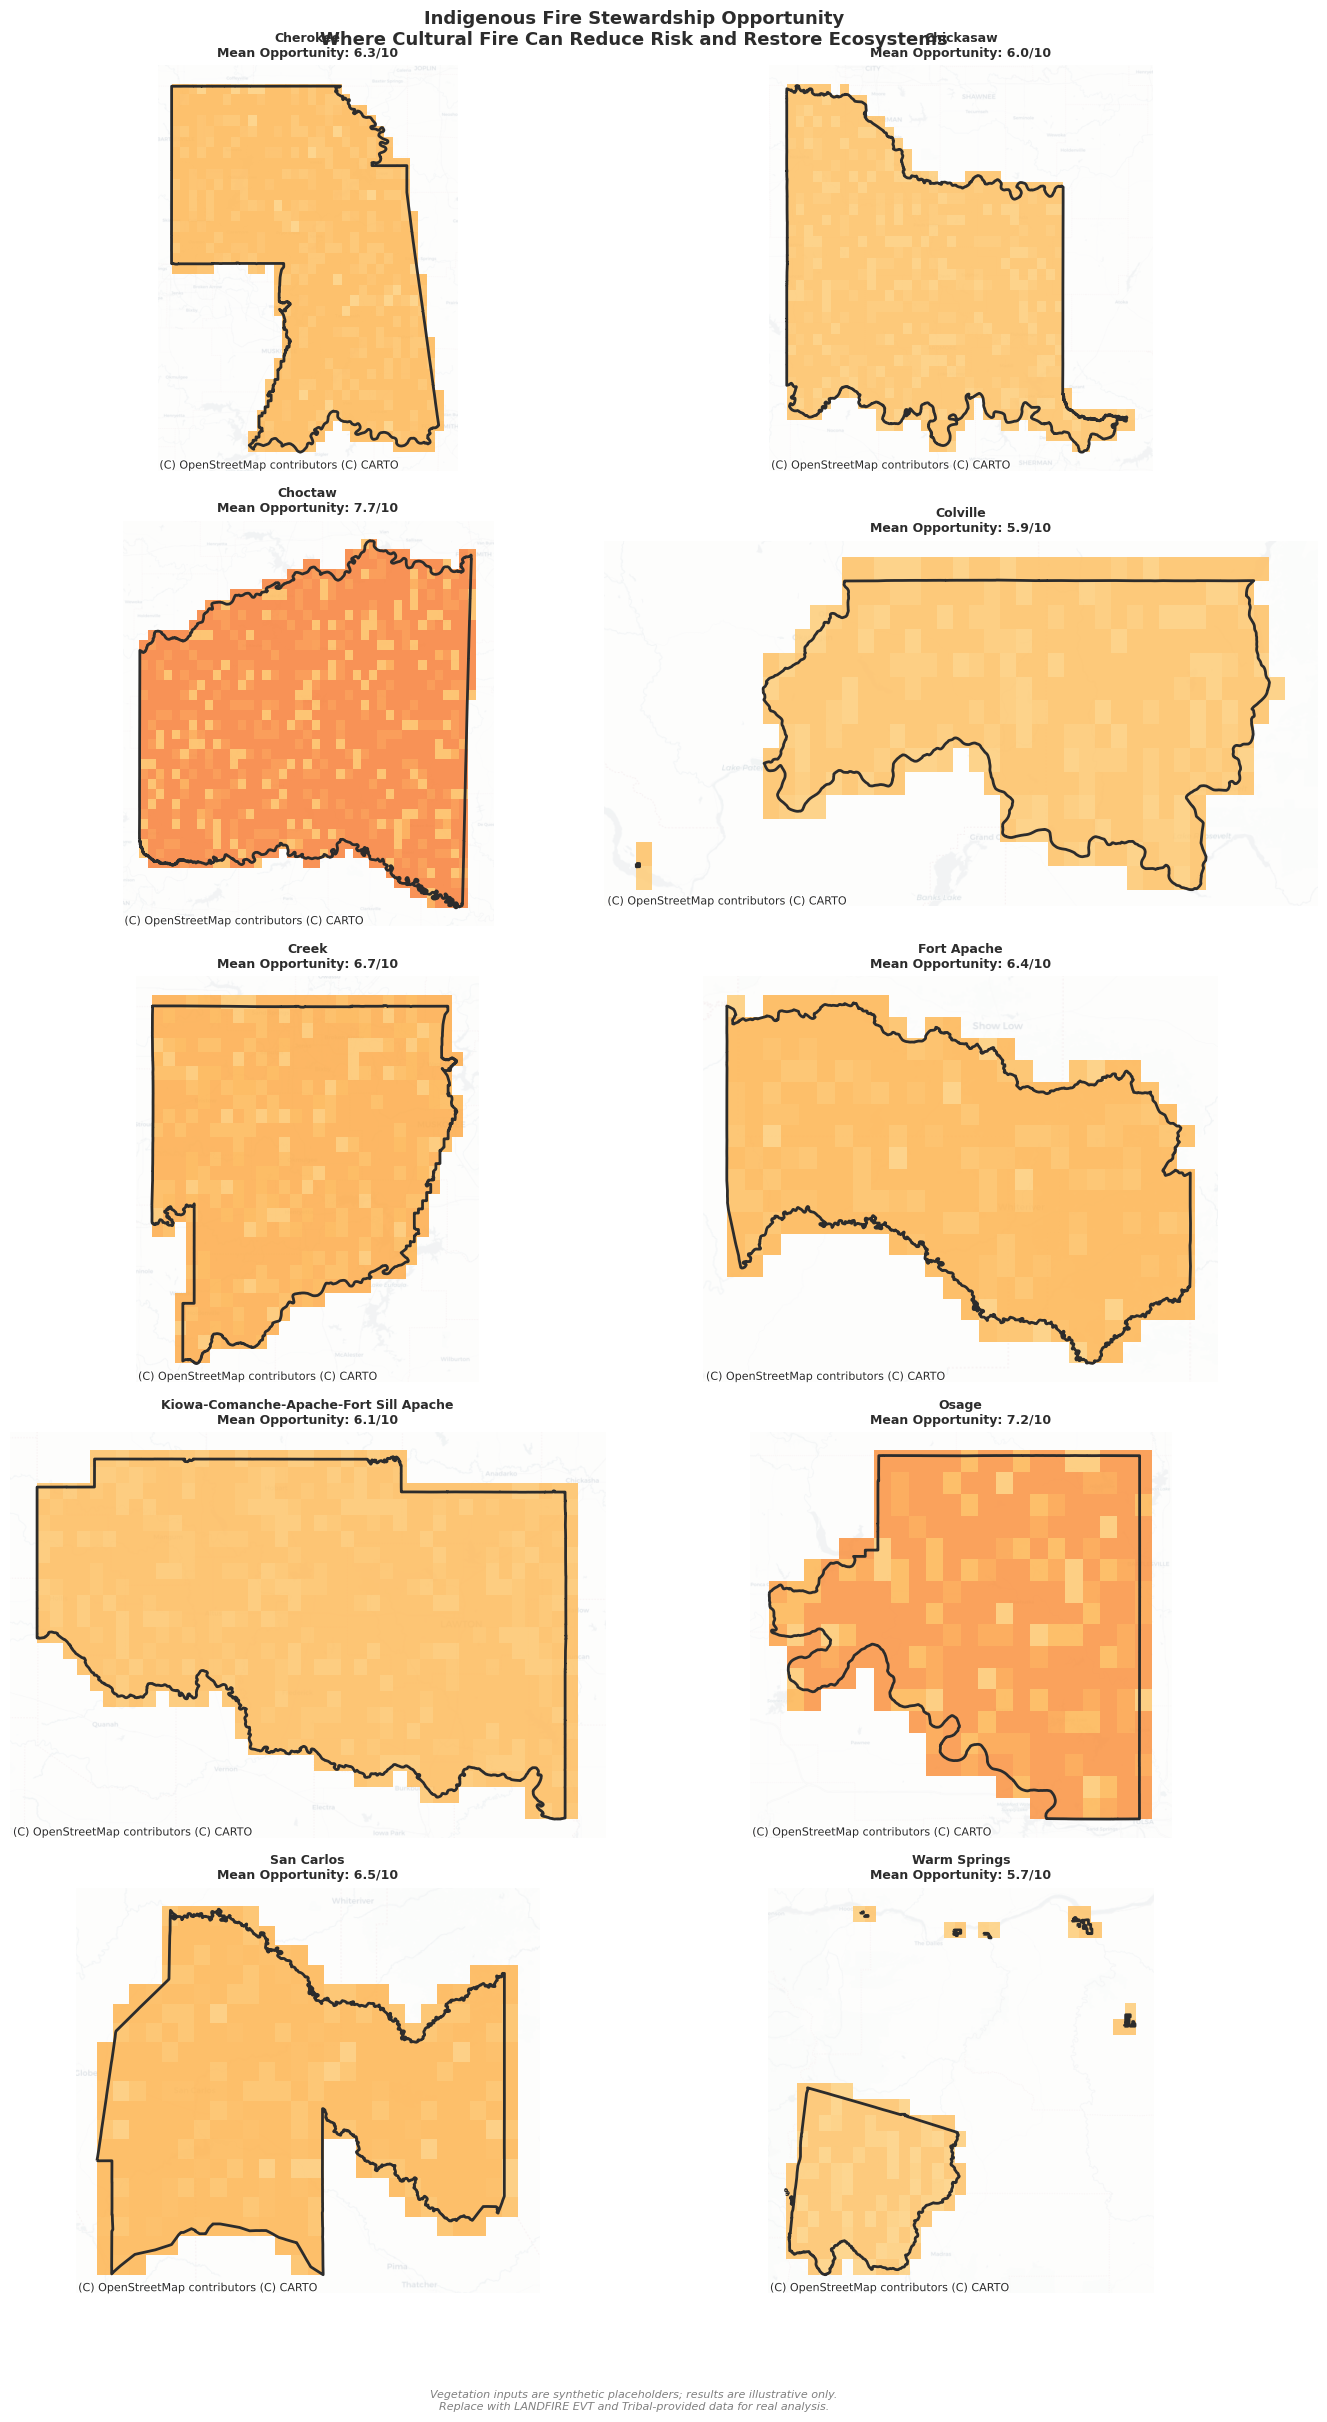

In [32]:
# Per-Tribe opportunity maps 
OPP_CMAP = LinearSegmentedColormap.from_list(
    "opportunity",
    ["#f0f0f0", "#ffffcc", "#feb24c", "#f03b20"],
    N=100,
)

n_tribes = len(tribal_lands)
ncols, nrows = 2, (n_tribes + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

for idx, (_, tribe_row) in enumerate(tribal_lands.iterrows()):
    ax   = axes[idx]
    name = tribe_row["NAME"]

    local_veg = vegetation[vegetation["NAME"] == name]
    if local_veg.empty:
        ax.set_title(name, fontsize=9)
        ax.axis("off")
        continue

    local_veg.to_crs(3857).plot(
        column="opportunity_score",
        cmap=OPP_CMAP,
        vmin=0, vmax=10,
        ax=ax, edgecolor="none", alpha=0.85,
    )
    gpd.GeoDataFrame(
        geometry=[tribe_row.geometry], crs=constants.CRS_GEOGRAPHIC
    ).to_crs(3857).boundary.plot(
        ax=ax, color=styles.CHARCOAL, linewidth=2
    )

    # Historical fire areas if available
    if not historical_fire_areas.empty:
        hist_local = historical_fire_areas[historical_fire_areas["NAME"] == name]
        if not hist_local.empty:
            hist_local.to_crs(3857).plot(
                ax=ax, facecolor="none",
                edgecolor="purple", linewidth=1.5, linestyle="--",
            )

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.3)
    except Exception:
        pass

    mean_opp = local_veg["opportunity_score"].mean()
    ax.set_title(
        f"{name}\nMean Opportunity: {mean_opp:.1f}/10",
        fontsize=9, fontweight="bold",
    )
    ax.set_axis_off()

for ax in axes[n_tribes:]:
    ax.set_visible(False)

fig.text(
    0.5, 0.02,
    "Vegetation inputs are synthetic placeholders; results are illustrative only.\n"
    "Replace with LANDFIRE EVT and Tribal-provided data for real analysis.",
    ha="center", fontsize=8, style="italic", color="gray",
)
plt.suptitle(
    "Indigenous Fire Stewardship Opportunity\n"
    "Where Cultural Fire Can Reduce Risk and Restore Ecosystems",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
charts.save_figure(fig, "outputs/figures/indigenous_fire_stewardship_opportunity.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\cultural_fire_cobenefits_dashboard.png


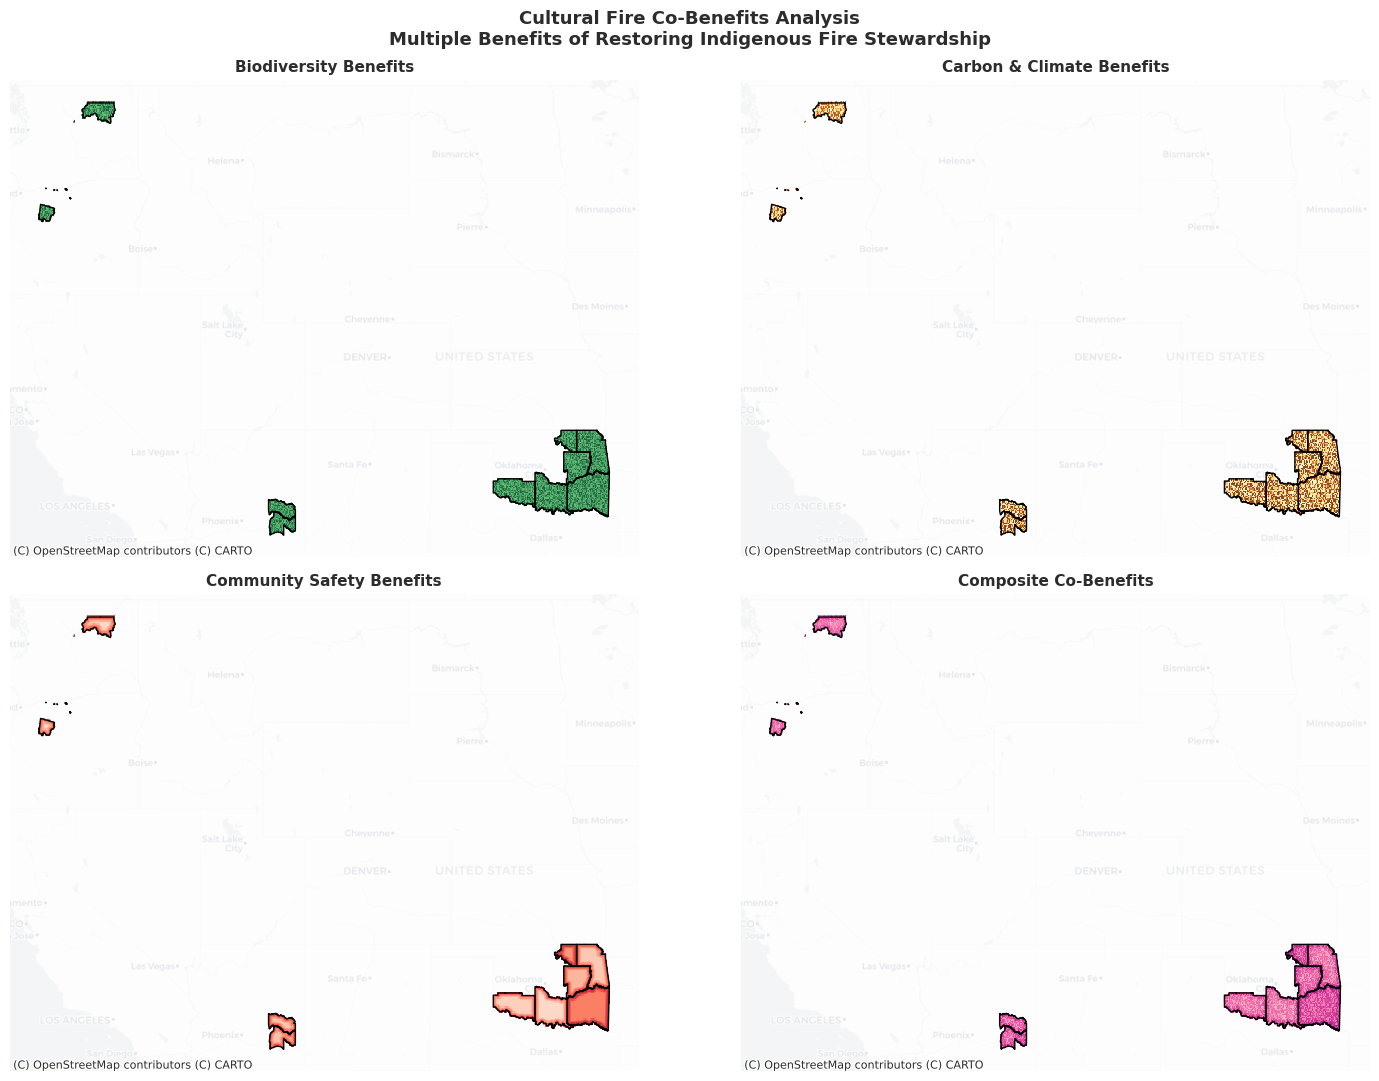

In [33]:
# Co-benefits dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

def _choropleth(ax, col, title, cmap):
    for _, tribe_row in tribal_lands.iterrows():
        name  = tribe_row["NAME"]
        local = vegetation[vegetation["NAME"] == name]
        if local.empty:
            continue
        local.to_crs(3857).plot(
            column=col, cmap=cmap, vmin=0, vmax=10,
            ax=ax, edgecolor="none", alpha=0.85,
        )
        gpd.GeoDataFrame(
            geometry=[tribe_row.geometry], crs=constants.CRS_GEOGRAPHIC
        ).to_crs(3857).boundary.plot(ax=ax, color="black", linewidth=1)
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.25)
    except Exception:
        pass
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_axis_off()

_choropleth(axes[0, 0], "biodiversity_benefit",    "Biodiversity Benefits",    "Greens")
_choropleth(axes[0, 1], "carbon_benefit_score",    "Carbon & Climate Benefits", "YlOrBr")
_choropleth(axes[1, 0], "community_safety_benefit", "Community Safety Benefits", "Reds")
_choropleth(axes[1, 1], "co_benefits_score",        "Composite Co-Benefits",    "RdPu")

plt.suptitle(
    "Cultural Fire Co-Benefits Analysis\n"
    "Multiple Benefits of Restoring Indigenous Fire Stewardship",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/cultural_fire_cobenefits_dashboard.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\cultural_fire_priority_rankings.png


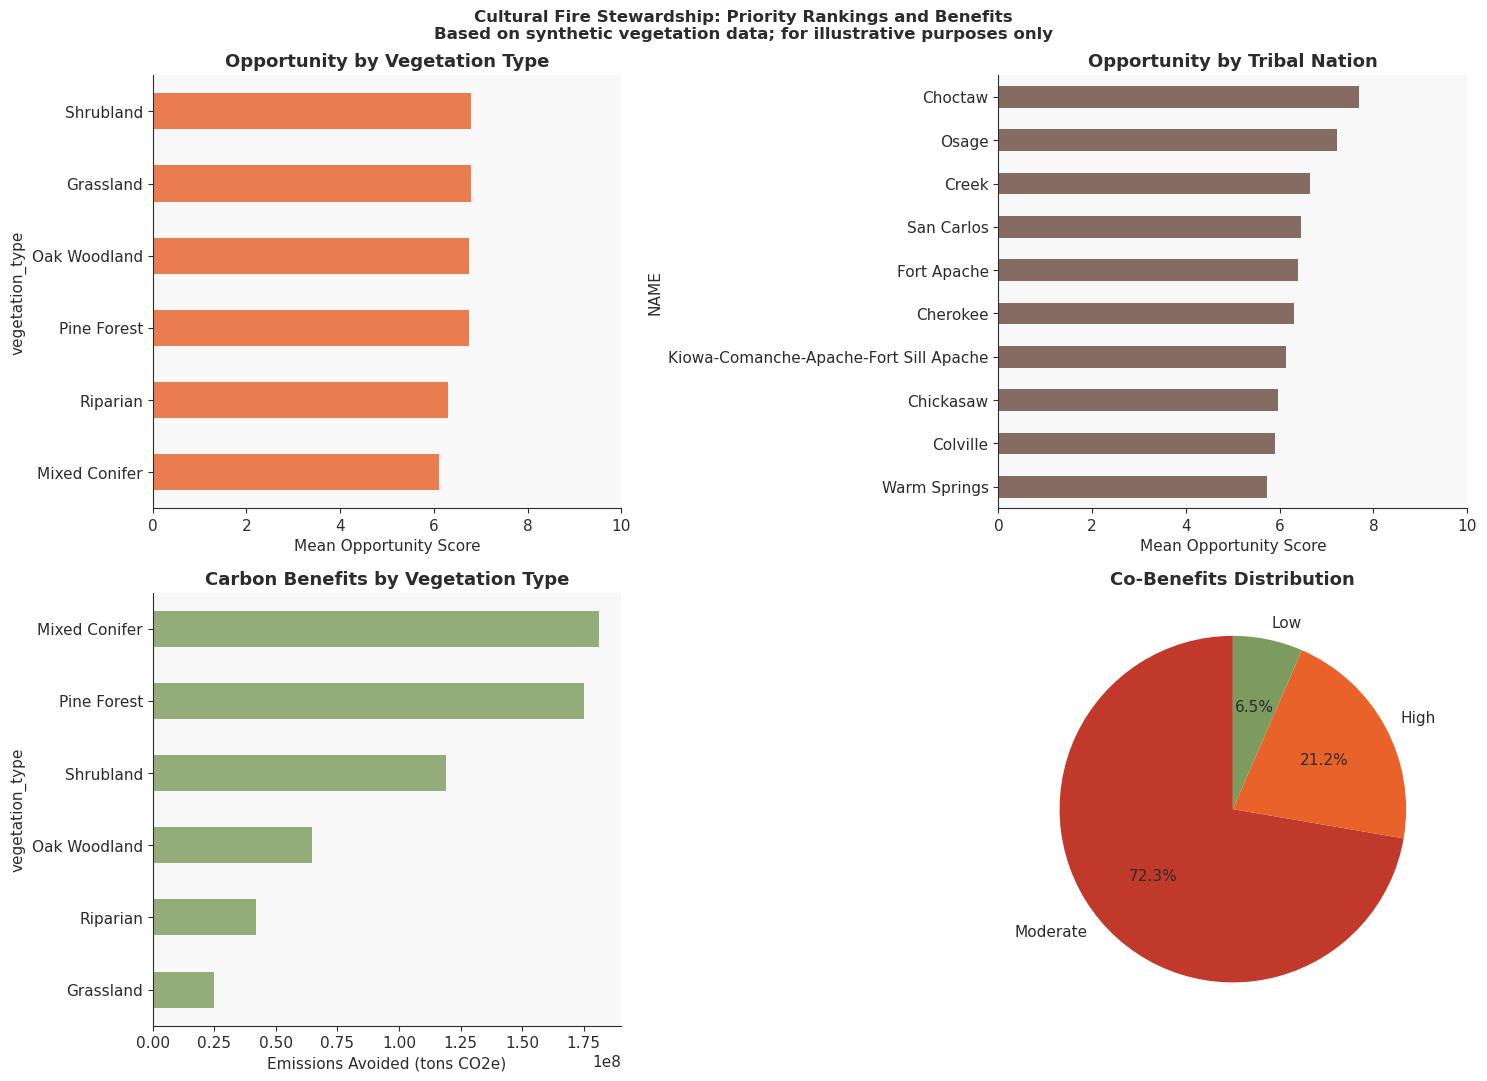

In [34]:
# Priority ranking charts 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Opportunity by vegetation type
veg_opp = (
    vegetation.groupby("vegetation_type")["opportunity_score"]
    .mean().sort_values()
)
veg_opp.plot(kind="barh", ax=axes[0, 0], color=styles.FIRE_ORANGE, alpha=0.82)
axes[0, 0].set_xlabel("Mean Opportunity Score")
axes[0, 0].set_title("Opportunity by Vegetation Type", fontweight="bold")
axes[0, 0].set_xlim(0, 10)
sns.despine(ax=axes[0, 0])

# Opportunity by Tribal Nation
tribe_opp = (
    vegetation.groupby("NAME")["opportunity_score"]
    .mean().sort_values()
)
tribe_opp.plot(kind="barh", ax=axes[0, 1], color=styles.EARTH_BROWN, alpha=0.82)
axes[0, 1].set_xlabel("Mean Opportunity Score")
axes[0, 1].set_title("Opportunity by Tribal Nation", fontweight="bold")
axes[0, 1].set_xlim(0, 10)
sns.despine(ax=axes[0, 1])

# Carbon benefits by vegetation type
carbon_veg = (
    vegetation.groupby("vegetation_type")["wildfire_emissions_avoided_tons"]
    .sum().sort_values()
)
carbon_veg.plot(kind="barh", ax=axes[1, 0], color=styles.SAGE_GREEN, alpha=0.82)
axes[1, 0].set_xlabel("Emissions Avoided (tons CO2e)")
axes[1, 0].set_title("Carbon Benefits by Vegetation Type", fontweight="bold")
sns.despine(ax=axes[1, 0])

# Co-benefits category distribution
co_counts = vegetation["co_benefits_category"].value_counts()
co_colors = [styles.EMBER_RED, styles.FIRE_ORANGE, styles.SAGE_GREEN]
axes[1, 1].pie(
    co_counts.values,
    labels=co_counts.index,
    colors=co_colors[:len(co_counts)],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1, 1].set_title("Co-Benefits Distribution", fontweight="bold")

plt.suptitle(
    "Cultural Fire Stewardship: Priority Rankings and Benefits\n"
    "Based on synthetic vegetation data; for illustrative purposes only",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/cultural_fire_priority_rankings.png")
plt.show()

## Exports

In [35]:
# Export spatial and tabular outputs 
export_cols = [
    "NAME", "vegetation_type", "opportunity_score", "opportunity_category",
    "ecological_suitability", "fire_risk_score", "accessibility_score",
    "biodiversity_benefit", "carbon_benefit_score", "community_safety_benefit",
    "co_benefits_score", "co_benefits_category",
    "area_acres", "wildfire_emissions_avoided_tons", "historical_use",
    "geometry",
]

vegetation[
    [c for c in export_cols if c in vegetation.columns]
].assign(
    opportunity_category=lambda df: df["opportunity_category"].astype(str),
    co_benefits_category=lambda df: df["co_benefits_category"].astype(str),
).to_file(
    constants.OUTPUTS_DIR / "cultural_fire_opportunity.geojson",
    driver="GeoJSON",
)
print("Exported to outputs/cultural_fire_opportunity.geojson")

# Summary by Tribal Nation
summary = (
    vegetation.groupby("NAME")
    .agg(
        total_acres=("area_acres", "sum"),
        mean_opportunity=("opportunity_score", "mean"),
        high_opportunity_acres=("area_acres", lambda x: x[vegetation.loc[x.index, "opportunity_category"] == "High"].sum()),
        mean_biodiversity=("biodiversity_benefit", "mean"),
        emissions_avoided_tons=("wildfire_emissions_avoided_tons", "sum"),
    )
    .round(1)
    .reset_index()
)
summary.to_csv(constants.OUTPUTS_DIR / "cultural_fire_summary_by_tribe.csv", index=False)
print("Exported to outputs/cultural_fire_summary_by_tribe.csv")
print("\nSummary:")
print(summary.sort_values("mean_opportunity", ascending=False).to_string(index=False))

Exported to outputs/cultural_fire_opportunity.geojson
Exported to outputs/cultural_fire_summary_by_tribe.csv

Summary:
                                  NAME  total_acres  mean_opportunity  high_opportunity_acres  mean_biodiversity  emissions_avoided_tons
                               Choctaw    7504255.6               7.7               6548028.1                7.9             129866380.7
                                 Osage    1735413.4               7.2               1385938.3                7.7              32253685.9
                                 Creek    3438355.3               6.7                     0.0                7.7              62527874.8
                            San Carlos    2270735.2               6.5                     0.0                7.8              40519508.0
                           Fort Apache    1970414.2               6.4                     0.0                7.8              34954631.6
                              Cherokee    4876343.9        

## Summary and Findings

*(Fill in after running; note which components used real vs. synthetic data.)*

**Data status summary:**
- Tribal boundaries: Real (Census TIGER AIANNH)
- Fire risk scores: Real if MTBS is loaded; neutral default otherwise
- Area / geometry calculations: Real
- Vegetation types: Synthetic; download LANDFIRE EVT to replace
- Historical fire areas: Empty; requires Tribal engagement
- Practitioners: Empty; requires Tribal engagement

**Questions:**
- Which Tribal lands show the highest composite opportunity scores, and what drives them?
- Where would restored cultural fire create the greatest co-benefits?
- What barriers exist at the federal and state level for each Tribal land, and how have similar Tribal Nations addressed them?
- What would direct engagement with Tribal fire stewards change about these findings?
  This framework provides a data-supported starting point, the real analysis
  happens in conversation with Tribal knowledge holders.

**Resources for real data and partnership:**
- Indigenous Peoples Burning Network: www.indigenouspeoplesburningnetwork.org
- LANDFIRE EVT: https://www.landfire.gov/evt.php
- TREX (Prescribed Fire Training Exchanges): https://www.conservationgateway.org/trex
- Fire Adapted Communities Network: https://fireadaptednetwork.org

---
## References

In [36]:
print(generate_citations(["census_aiannh", "mtbs"]))

References / Data Sources
----------------------------------------
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
- Monitoring Trends in Burn Severity (MTBS). USGS / USDA Forest Service. https://www.mtbs.gov
